# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:

print(california['DESCR'])  # descripción del dataset
#california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [6]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [7]:
y.shape

(20640,)

In [8]:
y_test.shape

(4128,)

---
## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

**Responder todas las preguntas acá.**


1. Es un conjunto de datos obtenido en base a grupos de bloques de un censo realizado en 1990 de California, Estados Unidos. Este se compone de $20640$ observaciones con $9$ variables diferentes.

***

2. La variable objetivo que hay que intentar predecir es: `MedHouseValue` (es el valor medio de las viviendas en los grupos de bloques)

***

3. Disponemos de los siguientes atributos:

    - `MedInc` :        Ingreso medio en el grupo de bloques
    - `HouseAge` :      Antiguedad media de la casa en el grupo de bloques
    - `AveRooms` :      Número promedio de habitaciones por vivienda
    - `AveBedrms` :     Número promedio de dormitorios por vivienda
    - `Population` :    Población total del grupo de bloques
    - `AveOccup` :      Número promedio de personas por vivienda
    - `Latitude` :      Latitud del grupo de bloque
    - `Longitude` :     Longitud del grupo de bloque

***

4. Considero que los más determinantes podrían ser: `AveRooms`, `MedInc`, `Latitude`, `Longitude`

Ya que:

- Lo primero nos da un indicio de qué tan grande es
- Lo segundo nos indica el ingreso del área (dando cierto "prestigio")
- Lo tercero nos dice en qué lugar está (más cerca del centro, más lejos, etc).

***

5. Algunas de las cosas que pienso que son importantes para hacer un análisis como este son:

- Presencia y calidad de servicios.
- Tamaño específico en metros cuadrados de la vivienda.
- Amueblamiento/equipamiento de la vivienda.

Sin embargo, estas no están presentes, pero en cambio si tenemos el ingreso medio por ejemplo, lo cual puede presentar un sesgo socioeconómico a la hora de trabajar con los datos.  


---
## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

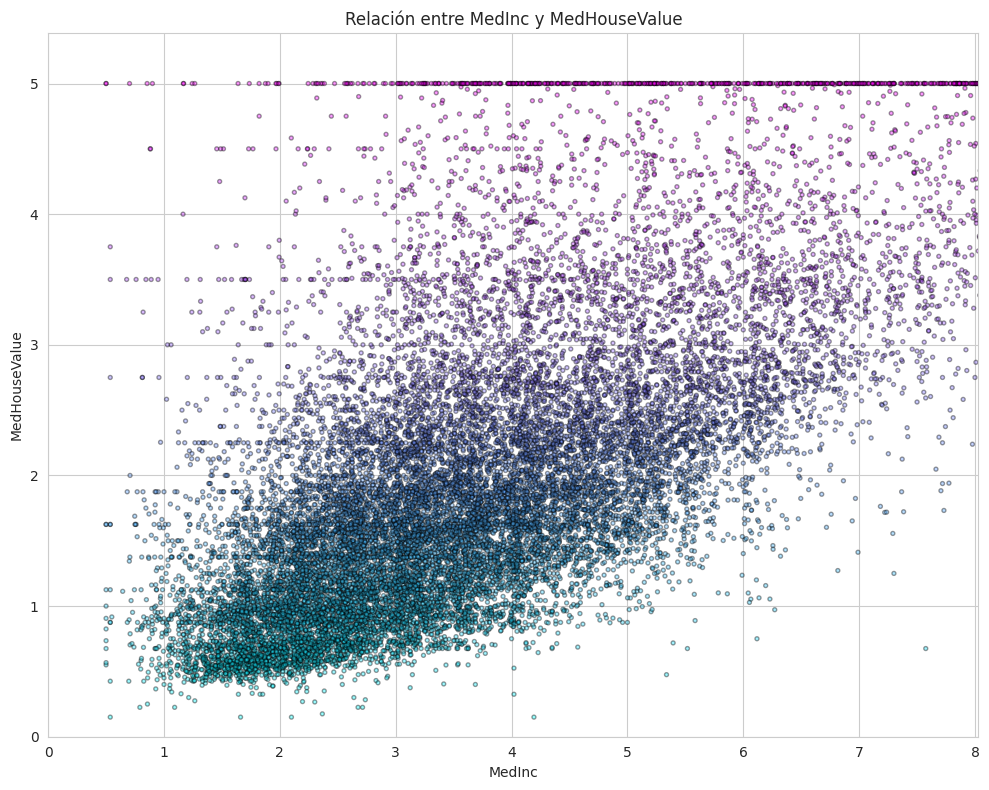

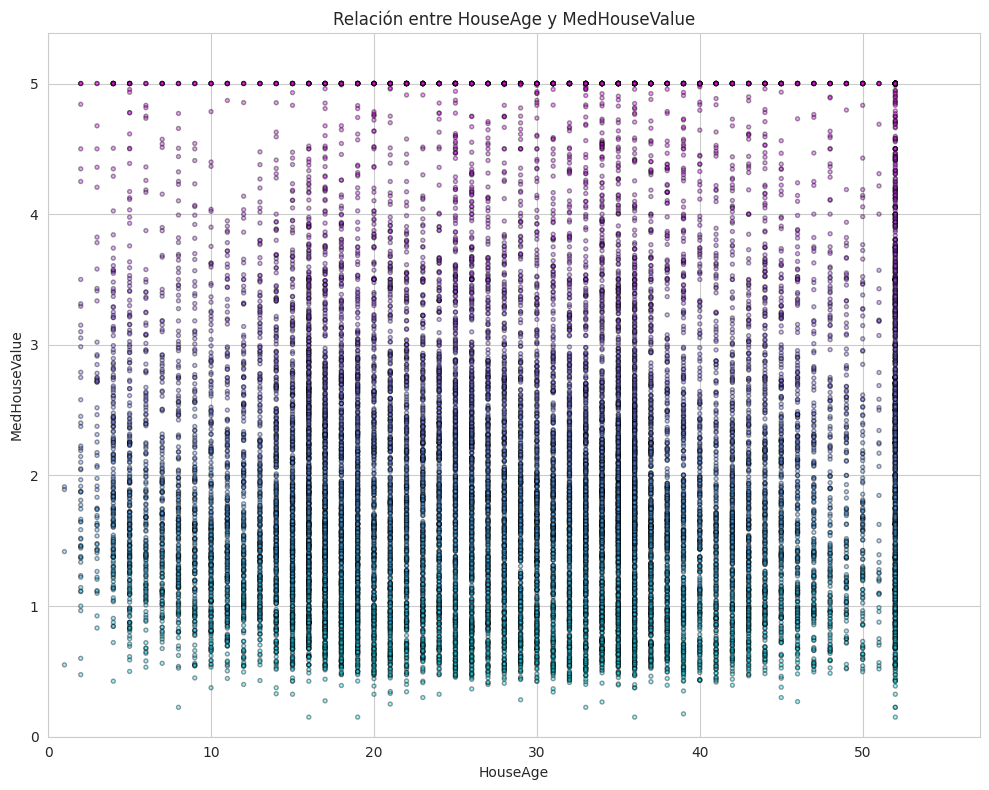

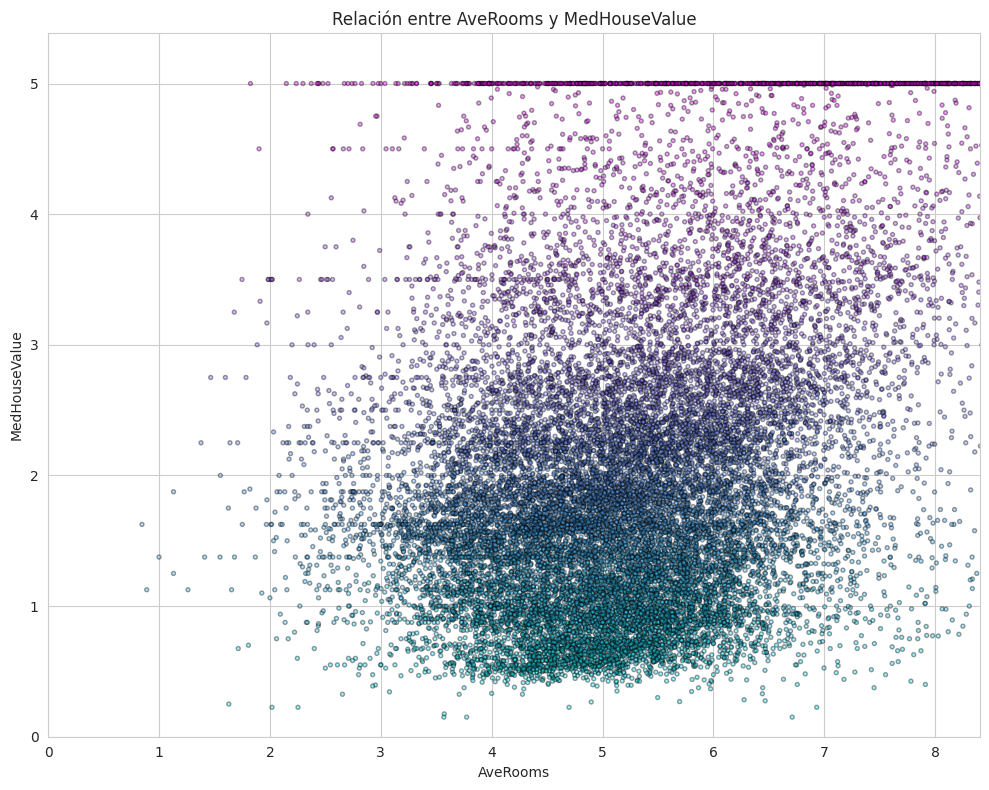

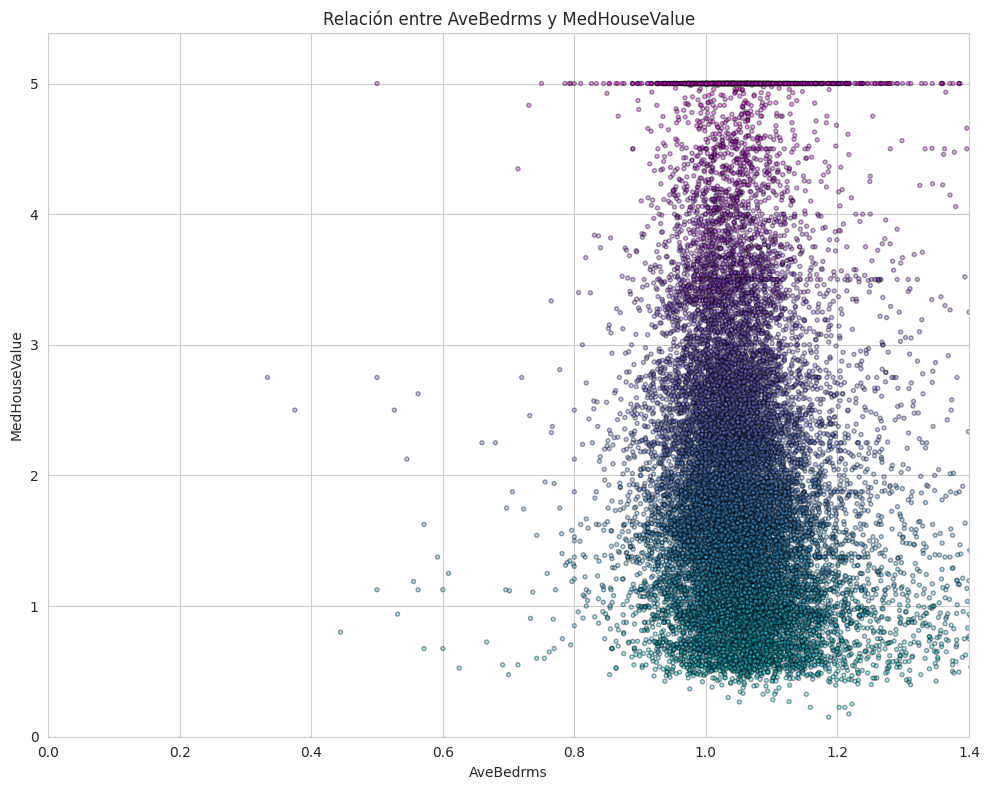

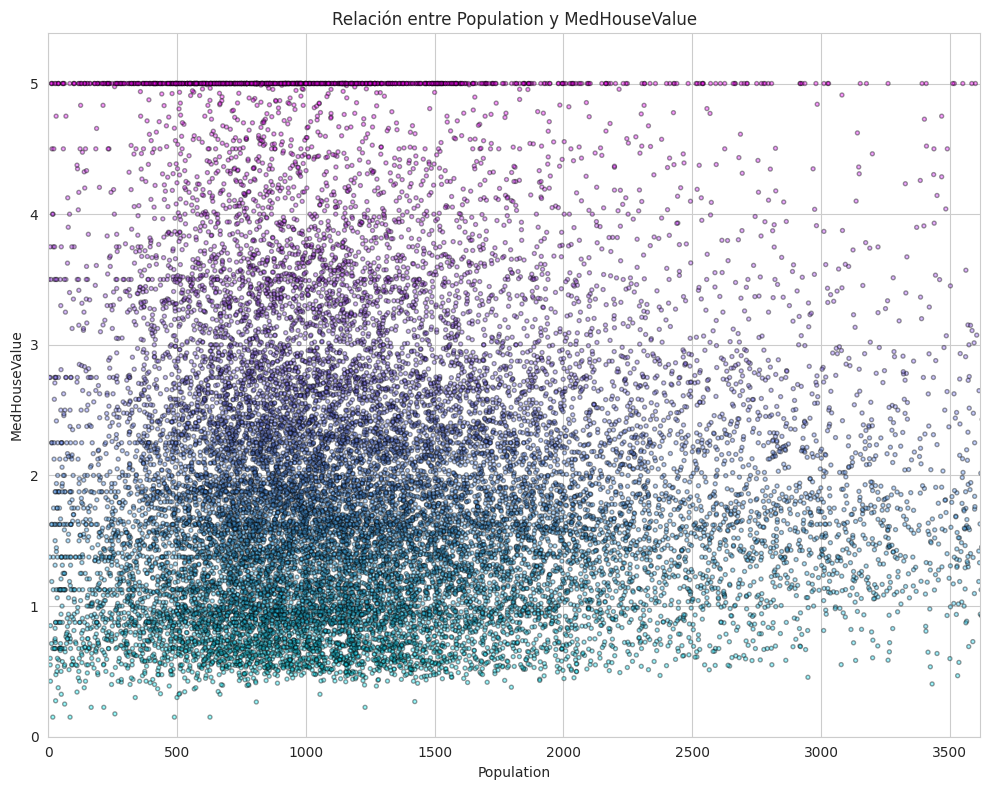

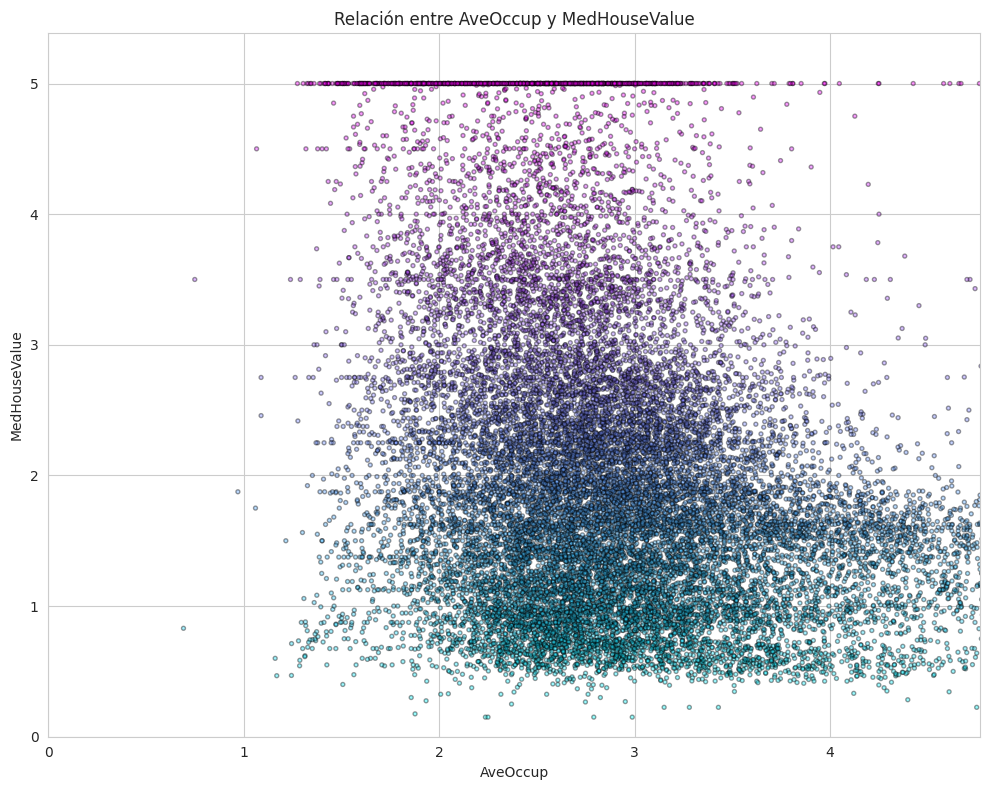

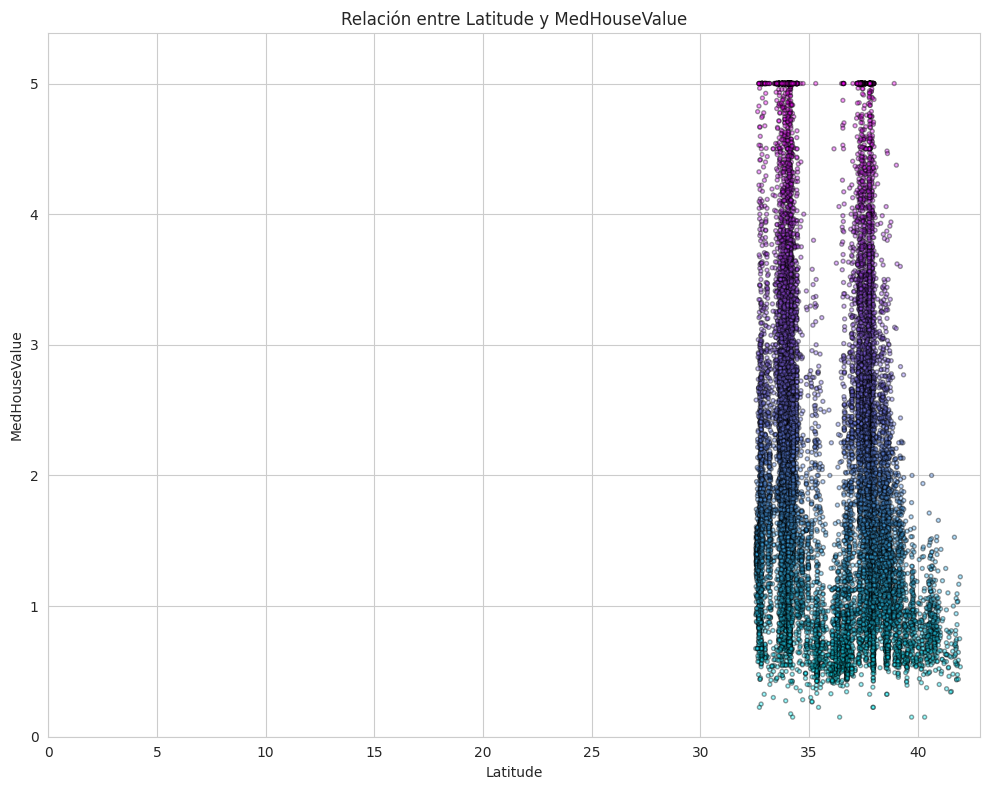

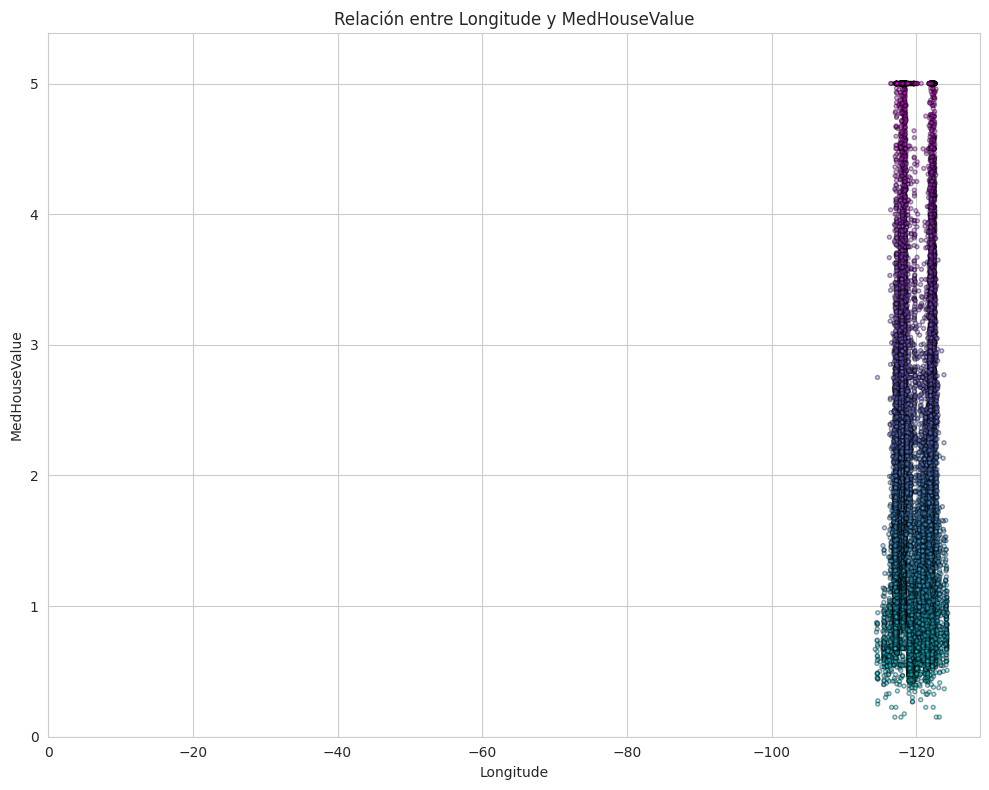

In [ ]:
# 1. Resolver acá. Ayuda/ejemplo:
import seaborn as sns
sns.set_style('whitegrid')

# Hago un bucle y utilizo cada índice de cada feature en X[:, i]
for i, feature in enumerate(california.feature_names):
    plt.figure(figsize=(10, 8))
    plt.scatter(X[:, i], y, c=y, cmap='cool', edgecolor="k", alpha=0.4, s=8)
    plt.title(f"Relación entre {feature} y MedHouseValue")
    plt.xlabel(feature)
    plt.ylabel("MedHouseValue")

    # Set axis limits to focus on main distribution (95th percentile)
    x_95 = np.percentile(X[:, i], 95)
    y_95 = np.percentile(y, 95)
    plt.xlim(0, x_95 * 1.1)
    plt.ylim(0, y_95 * 1.1)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
california['feature_names'][1] == feature

False

**3.** Los atributos que son más informativos para la predicción son:

`MedInc`, `Latitude`, `Longitude`

---
## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

In [11]:
# 1. Resolver acá. Ayuda:
feature = 'MedInc'  # selecciono el atributo 'MedInc'
selector = california['feature_names'].index(feature)
selector = (np.array(california['feature_names']) ==  feature)
X_train_f = X_train[:, selector]
X_test_f = X_test[:, selector]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [12]:
X_train_f[1]

array([4.3898])

In [13]:
# 2. Instanciar y entrenar acá.

# Una observación antes de empezar:
# los tipos de datos son todos numéricos y no hay valores nulos, por lo que es posible aplicar la regresión sin problemas

import pandas as pd

df = pd.DataFrame(california.data, columns=california.feature_names)

print(f"Dtypes:\n {df.dtypes}\n")
print(f"Valores null:\n {df.isnull().sum()}\n")

# ----------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_f, y_train)

Dtypes:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

Valores null:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# 3. Predecir y evaluar acá.

y_pred_train = model.predict(X_train_f)
y_pred_test = model.predict(X_test_f)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"Training MSE: {mse_train:.4f}")
print(f"Eval MSE: {mse_test:.4f}")

Training MSE: 0.6961
Eval MSE: 0.7215


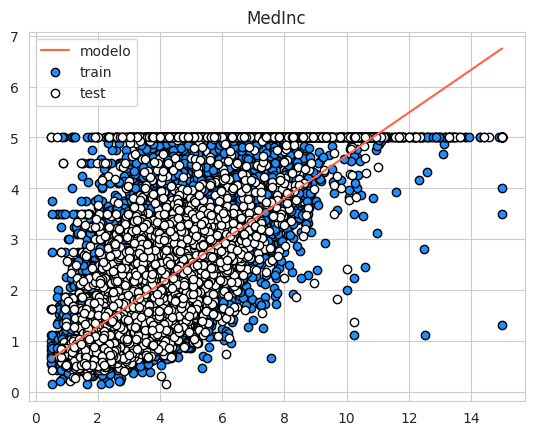

In [15]:
# 4. Graficar acá. Ayuda:
x_start = min(np.min(X_train_f), np.min(X_test_f))
x_end = max(np.max(X_train_f), np.max(X_test_f))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)
plt.plot(x, model.predict(x), color="tomato", label="modelo")

plt.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", label="test")
plt.title(feature)
plt.legend()
plt.show()

#### 5. Responder acá

En base a la gráfica obtenida observamos que la dirección de la recta del modelo coincide con la tendencia general de los datos.

---
## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [16]:
# 1. Resolver acá.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
train_errors = []
test_errors = []

for degree in degrees:

    # Training
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train_f, y_train)

    # Predict
    y_train_pred = model.predict(X_train_f)
    y_test_pred = model.predict(X_test_f)

    # Eval
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_error)
    test_errors.append(test_error)

    print(f"Polinomio grado {degree}: Training MSE = {train_error:.4f}, Eval MSE = {test_error:.4f}")

Polinomio grado 0: Training MSE = 1.3384, Eval MSE = 1.3043
Polinomio grado 1: Training MSE = 0.6961, Eval MSE = 0.7215
Polinomio grado 2: Training MSE = 0.6895, Eval MSE = 0.7174
Polinomio grado 3: Training MSE = 0.6782, Eval MSE = 0.7081
Polinomio grado 4: Training MSE = 0.6781, Eval MSE = 0.7080
Polinomio grado 5: Training MSE = 0.6780, Eval MSE = 0.7080
Polinomio grado 6: Training MSE = 0.6761, Eval MSE = 0.7068
Polinomio grado 7: Training MSE = 0.6737, Eval MSE = 0.7026
Polinomio grado 8: Training MSE = 0.6736, Eval MSE = 0.7021
Polinomio grado 9: Training MSE = 0.6741, Eval MSE = 0.7028


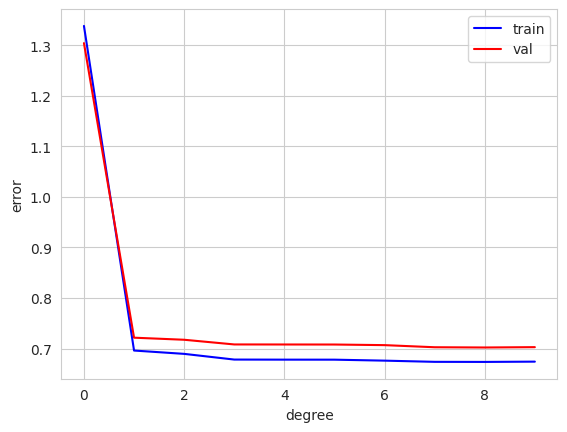

In [17]:
# 2. Graficar curvas de error acá.

# Graficar curva de errores

plt.plot(degrees, train_errors, color="blue", label="train")
plt.plot(degrees, test_errors, color="red", label="val")
plt.legend()
plt.xlabel("degree")
plt.ylabel("error")
plt.show()

#### 3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.

- Grados 0-1: Subajuste (underfitting) - modelo demasiado simple
- Grados 2-3: Zona óptima - buen balance entre sesgo y varianza
- Grado 4 en adelante: Sobreajuste (overfitting) - el error de validación aumenta mientras el de entrenamiento se mantiene bajo

- Punto de sobreajuste: Comienza aproximadamente en el grado 4, donde las curvas empiezan a diverger.
- Modelo recomendado: Grado 2-3 para mejor generalización.

#### 4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.

Grado:8
Comparando modelos de grado 8 y 3


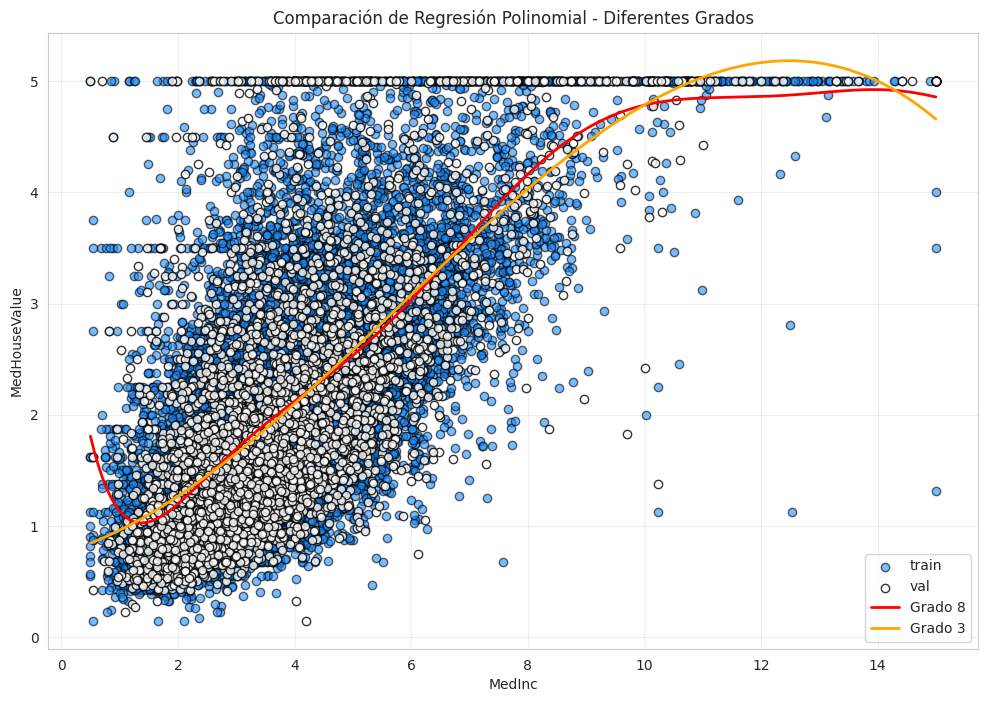

In [ ]:
# 4:

# Definir los grados a comparar
# Se selecciona el grado con el menor error de validación (el más preciso)
degree1 = degrees[np.argmin(test_errors)]
print(f"Grado:{degree1}")
# Se elige otro grado para comparar
degree2 = 3

# Entrenar modelo 1
model1 = make_pipeline(PolynomialFeatures(degree1), LinearRegression())
model1.fit(X_train_f, y_train)

# Entrenar modelo 2
model2 = make_pipeline(PolynomialFeatures(degree2), LinearRegression())
model2.fit(X_train_f, y_train)

print(f"Comparando modelos de grado {degree1} y {degree2}")

# Crear la gráfica
plt.figure(figsize=(12, 8))

# Datos de entrenamiento y validación
plt.scatter(X_train_f, y_train, color="dodgerblue", edgecolor="k", label="train", alpha=0.6)
plt.scatter(X_test_f, y_test, color="white", edgecolor="k", label="val", alpha=0.8)

# Predicciones de ambos modelos
plt.plot(x, model1.predict(x), color="red", linewidth=2, label=f"Grado {degree1}")
plt.plot(x, model2.predict(x), color="orange", linewidth=2, label=f"Grado {degree2}")

plt.title("Comparación de Regresión Polinomial - Diferentes Grados")
plt.xlabel(feature)
plt.ylabel("MedHouseValue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Comparación entre modelos y conclusiones
#### Modelo de grado 8

**Ventajas:**
* Presenta el menor error de validación (`Eval MSE = 0.7021`), por lo tanto, es el más preciso en términos numéricos sobre el conjunto de evaluación.
* Capta mejor las pequeñas variaciones en los datos de entrenamiento.

**Desventajas:**
* Riesgo elevado de sobreajuste (overfitting), ajustándose no solo a la tendencia sino también al ruido de los datos.
* Menor capacidad de generalización a nuevos datos.

#### Modelo de grado 3

**Ventajas:**
* Menor riesgo de sobreajuste.
* Buen equilibrio entre precisión y generalización.
* La diferencia de error respecto al modelo de grado 8 es muy pequeña (`Eval MSE = 0.7081`), lo que lo hace competitivo.

**Desventajas:**
* No capta algunas de las pequeñas fluctuaciones presentes en los datos.
* Ligeramente menos preciso en el conjunto de evaluación según el MSE.

---
## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [ ]:
# 1. Resolver acá. Ayuda (con dos atributos):
selector = (
    (np.array(california['feature_names']) == 'Latitude') |
    (np.array(california['feature_names']) == 'Longitude') |
    (np.array(california['feature_names']) == 'MedInc')
)

X_train_fs = X_train[:, selector]
X_test_fs = X_test[:, selector]
X_train_fs.shape, X_test_fs.shape

X_train_fs[1]

array([   4.3898,   37.73  , -122.44  ])

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
train_errors = []
test_errors = []

for degree in degrees:

    # Training
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train_fs, y_train)

    # Predict
    y_train_pred = model.predict(X_train_fs)
    y_test_pred = model.predict(X_test_fs)

    # Eval
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_error)
    test_errors.append(test_error)

    print(f"Polinomio grado {degree}: Training MSE = {train_error:.4f}, Eval MSE = {test_error:.4f}")

Polinomio grado 0: Training MSE = 1.3384, Eval MSE = 1.3043
Polinomio grado 1: Training MSE = 0.5508, Eval MSE = 0.5650
Polinomio grado 2: Training MSE = 0.5224, Eval MSE = 0.5360
Polinomio grado 3: Training MSE = 0.5063, Eval MSE = 0.5163
Polinomio grado 4: Training MSE = 0.4908, Eval MSE = 0.5019
Polinomio grado 5: Training MSE = 0.4858, Eval MSE = 0.4957
Polinomio grado 6: Training MSE = 0.4780, Eval MSE = 0.4897
Polinomio grado 7: Training MSE = 0.4723, Eval MSE = 0.4820
Polinomio grado 8: Training MSE = 0.4658, Eval MSE = 0.4761
Polinomio grado 9: Training MSE = 0.4660, Eval MSE = 0.4763


**3. Conclusiones**

* La combinación de `MedInc`, `Latitude` y `Longitude` logró un **Eval MSE de 0.4761**, significativamente mejor que usar `MedInc` solo (**≈ 0.7021**) o `Latitude` y `Longitude` (**≈ 0.8883**).
* El error **disminuye consistentemente** hasta el grado 8, donde alcanza su mínimo.
* El modelo **no muestra señales claras de sobreajuste**, ya que los errores de evaluación siguen disminuyendo o se mantienen estables.

---
## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?
